# Quantium Customer & Chip Sales Analysis

## Project Overview

This project analyzes transaction and customer purchasing data to understand chip purchasing behaviour across different customer life stages and customer segments.

The analysis focuses on:
- Transaction trends over time.
- Chip pack-size preferences.
- Customer life-stage purchasing behaviour.
- Budget, Mainstream, and Premium customer segments.
- Sales, quantity, and average unit price across customer groups.
- Mainstream customer behaviour.
- Relative brand and pack-size sales representation.

## Business Objectives

1. Understand overall transaction and sales patterns.
2. Identify the most popular chip pack sizes.
3. Determine which customer life stages contribute most to sales.
4. Compare purchasing behaviour across Budget, Mainstream, and Premium customers.
5. Identify customer groups that may be valuable for further analysis.
6. Explore brand and pack-size preferences within a selected target group.
7. Use statistical testing to assess whether observed transaction-value differences are statistically significant.

> **Analytical note:** This project is observational. The analysis identifies patterns and associations in the transaction data; it does not establish causal relationships.

In [1]:
import re
from datetime import datetime
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
excel_file = pd.ExcelFile('QVI_transaction_data.xlsx')
sheet_names = excel_file.sheet_names
#checking number of excel files & it's name
print(sheet_names)

['in']


In [3]:
df1 = pd.read_excel('QVI_transaction_data.xlsx')

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


## 2. Data Types and Memory Optimization

The raw transaction dataset contains several columns whose data types can be optimized for analytical processing.

I will:
- Convert the Excel serial date into a Pandas datetime.
- Convert integer columns to `int32` where appropriate.
- Convert sales values to `float32`.
- Convert repeated identifiers such as store, loyalty card, and product numbers to Pandas `category`.

This reduces memory usage while preserving the information required for analysis.

In [4]:
df1['DATE'] = pd.to_datetime(df1['DATE'], unit='D', origin='1899-12-30')

def dtype_validator(data):
    catergorical_data = data.select_dtypes(include= 'object').columns.tolist()

    numerical_data = data.select_dtypes(include= 'int64').columns.tolist()

    floating_data = data.select_dtypes(include= 'float64').columns.tolist()

    return numerical_data, catergorical_data, floating_data

numerical_data, catergorical_data, floating_data = dtype_validator(df1)


In [5]:
df1[numerical_data] = df1[numerical_data].astype('int32')
df1[floating_data] = df1[floating_data].astype('float32')
df1[['STORE_NBR','LYLTY_CARD_NBR' ,'PROD_NBR']] = df1[['STORE_NBR','LYLTY_CARD_NBR','PROD_NBR']].astype('category')

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   DATE            264836 non-null  datetime64[ns]
 1   STORE_NBR       264836 non-null  category      
 2   LYLTY_CARD_NBR  264836 non-null  category      
 3   TXN_ID          264836 non-null  int32         
 4   PROD_NBR        264836 non-null  category      
 5   PROD_NAME       264836 non-null  object        
 6   PROD_QTY        264836 non-null  int32         
 7   TOT_SALES       264836 non-null  float32       
dtypes: category(3), datetime64[ns](1), float32(1), int32(2), object(1)
memory usage: 10.6+ MB


## 3. Load Customer Purchase Behaviour

A second dataset contains customer-level attributes:
- Loyalty card number
- Life stage
- Customer segment

These attributes will be joined to the transaction data so that purchasing behaviour can be analyzed across different customer groups.

In [6]:
df2 = pd.read_csv('QVI_purchase_behaviour.csv')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


## 4. Combine Transaction and Customer Data

The two datasets are joined using `LYLTY_CARD_NBR` as the common customer identifier.

This creates a single analytical dataset containing:

- **Transaction information:** what was purchased, when, where, and for how much.
- **Customer information:** customer life stage and customer segment.

The combined dataset will be used for the remaining analysis.

In [7]:
num_data, categ_data, float_data = dtype_validator(df2)

df2[num_data] = df2[num_data].astype('int32')
df2['PREMIUM_CUSTOMER'] = df2['PREMIUM_CUSTOMER'].astype('category')

df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   LYLTY_CARD_NBR    72637 non-null  int32   
 1   LIFESTAGE         72637 non-null  object  
 2   PREMIUM_CUSTOMER  72637 non-null  category
dtypes: category(1), int32(1), object(1)
memory usage: 922.4+ KB


In [8]:
df2 = df2.drop_duplicates(subset= 'LYLTY_CARD_NBR', keep= 'first')
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   LYLTY_CARD_NBR    72637 non-null  int32   
 1   LIFESTAGE         72637 non-null  object  
 2   PREMIUM_CUSTOMER  72637 non-null  category
dtypes: category(1), int32(1), object(1)
memory usage: 922.4+ KB


## 5. Data Cleaning

Before performing the analysis, I standardize several text fields to improve consistency.

The cleaning process includes:
- Removing unnecessary spaces from product names.
- Removing special characters from product names.
- Standardizing life-stage labels.
- Checking for missing values.

The goal is to ensure that equivalent products and customer groups are treated consistently during aggregation and visualization.

In [9]:
data = df1.merge(df2, on= 'LYLTY_CARD_NBR', how= 'inner')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264836 non-null  datetime64[ns]
 1   STORE_NBR         264836 non-null  category      
 2   LYLTY_CARD_NBR    264836 non-null  int32         
 3   TXN_ID            264836 non-null  int32         
 4   PROD_NBR          264836 non-null  category      
 5   PROD_NAME         264836 non-null  object        
 6   PROD_QTY          264836 non-null  int32         
 7   TOT_SALES         264836 non-null  float32       
 8   LIFESTAGE         264836 non-null  object        
 9   PREMIUM_CUSTOMER  264836 non-null  category      
dtypes: category(3), datetime64[ns](1), float32(1), int32(3), object(2)
memory usage: 11.1+ MB


In [10]:
safe_data = data.copy()

safe_data['PROD_NAME'] = safe_data['PROD_NAME'].str.replace(r' +',' ',regex= True)
safe_data['PROD_NAME'] = safe_data['PROD_NAME'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)
safe_data['LIFESTAGE'] = safe_data.LIFESTAGE.str.title()


safe_data.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

## 6. Handling Unusually Large Purchase Quantities

Some transactions contain unusually high product quantities.

For the main analysis, transactions with `PROD_QTY >= 10` are treated as unusual observations and are kept separately for review.

A high quantity could represent:
- A genuine bulk purchase.
- A party or event purchase.
- A possible data-entry issue.

Because the available data does not allow these cases to be distinguished with certainty, the observations are retained separately while the cleaned dataset is used for the primary customer-behaviour analysis.

> **Note:** The quantity threshold is a business-rule assumption and should ideally be validated against the original business context.

In [11]:
safe_data = data[data["PROD_QTY"] < 10].copy()
outliers = data[data['PROD_QTY'] > 10]
safe_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 264834 entries, 0 to 264835
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              264834 non-null  datetime64[ns]
 1   STORE_NBR         264834 non-null  category      
 2   LYLTY_CARD_NBR    264834 non-null  int32         
 3   TXN_ID            264834 non-null  int32         
 4   PROD_NBR          264834 non-null  category      
 5   PROD_NAME         264834 non-null  object        
 6   PROD_QTY          264834 non-null  int32         
 7   TOT_SALES         264834 non-null  float32       
 8   LIFESTAGE         264834 non-null  object        
 9   PREMIUM_CUSTOMER  264834 non-null  category      
dtypes: category(3), datetime64[ns](1), float32(1), int32(3), object(2)
memory usage: 13.1+ MB


## 7. Product Feature Engineering

The product name contains useful information that is not directly available as separate columns.

I extract two additional features:

### Brand
The first part of the product name is used to identify the brand, followed by standardization of abbreviated brand names.

### Pack Size
The numerical value in the product name is extracted as the product pack size in grams.

These engineered features allow purchasing behaviour to be analyzed by brand and pack size rather than treating every product name as an unrelated category.

In [12]:
def rename_func(x):
    correct_name = {'WW':'Woolworths','NCC': 'Natural','Red': 'RRD','Snbts':'Sunbites',
                    'Infzns':'Infuzions','Dorito':'Doritos','Smith':'Smiths','Grain':'GrnWves'}

    x['BRAND'] = x['PROD_NAME'].str.split().str[0].replace(correct_name)
    x['PROD_NAME'] = x['PROD_NAME'].str.replace(r' +',' ',regex= True)
    x['PROD_NAME'] = x['PROD_NAME'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

    return x

safe_data = rename_func(safe_data)

In [13]:
size = []
list_of_prdcts = safe_data['PROD_NAME'].str.split()

for product_words in list_of_prdcts:
    for word in product_words:
        numbers = re.findall(r'\d+', word)
        if numbers:
            size.append(int(numbers[0]))


safe_data['SIZE'] = pd.DataFrame(size, index= safe_data.index)

safe_data['SIZE'] = safe_data['SIZE'].astype('int16')

is_salsa_dip = safe_data['PROD_NAME'].str.contains('salsa | dip',case= False)

safe_data = safe_data[~ is_salsa_dip]

safe_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246740 entries, 0 to 264835
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   DATE              246740 non-null  datetime64[ns]
 1   STORE_NBR         246740 non-null  category      
 2   LYLTY_CARD_NBR    246740 non-null  int32         
 3   TXN_ID            246740 non-null  int32         
 4   PROD_NBR          246740 non-null  category      
 5   PROD_NAME         246740 non-null  object        
 6   PROD_QTY          246740 non-null  int32         
 7   TOT_SALES         246740 non-null  float32       
 8   LIFESTAGE         246740 non-null  object        
 9   PREMIUM_CUSTOMER  246740 non-null  category      
 10  BRAND             246740 non-null  object        
 11  SIZE              246740 non-null  int16         
dtypes: category(3), datetime64[ns](1), float32(1), int16(1), int32(3), object(3)
memory usage: 14.6+ MB


## 8. Transaction Trends Over Time

### Business Question

How does transaction activity change over the analysis period?

I aggregate the number of transactions by date to identify:
- Overall purchasing patterns.
- Unusual spikes or drops.
- Periods that may require further investigation.

A shorter date range is also examined separately to inspect transaction activity at a more granular level.

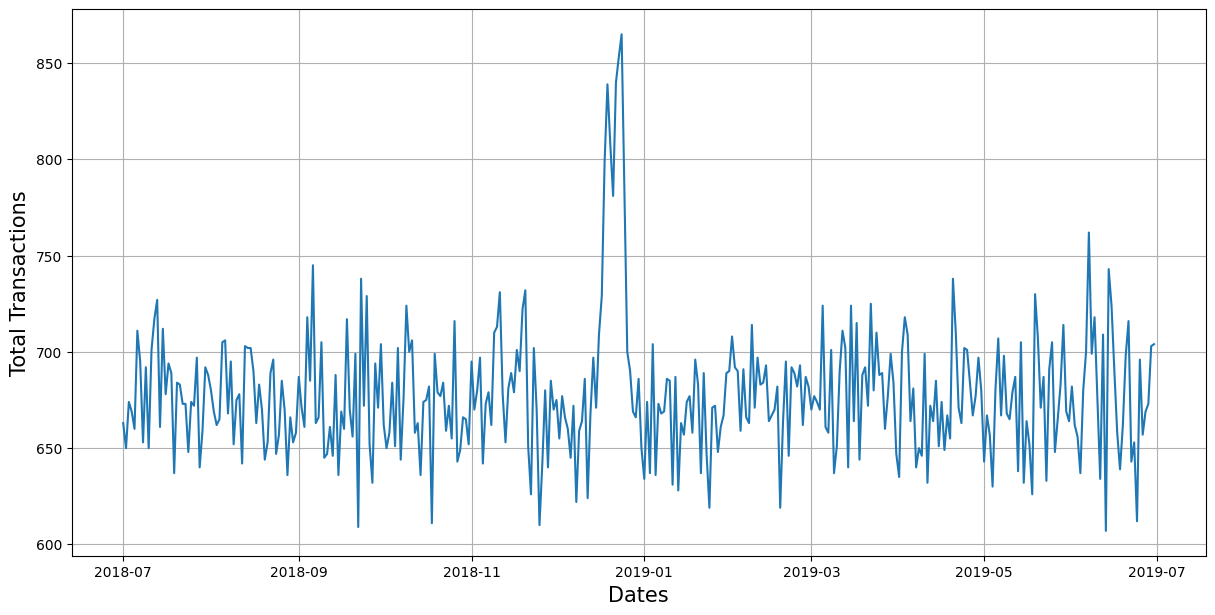

In [14]:

test = safe_data.groupby('DATE')['TXN_ID'].count()

plt.figure(figsize= (12,6))
plt.plot(test )
plt.tight_layout()
plt.xlabel('Dates', fontsize= 15)
plt.ylabel('Total Transactions', fontsize= 15)
plt.grid(True)

Text(0, 0.5, 'Total Transactions')

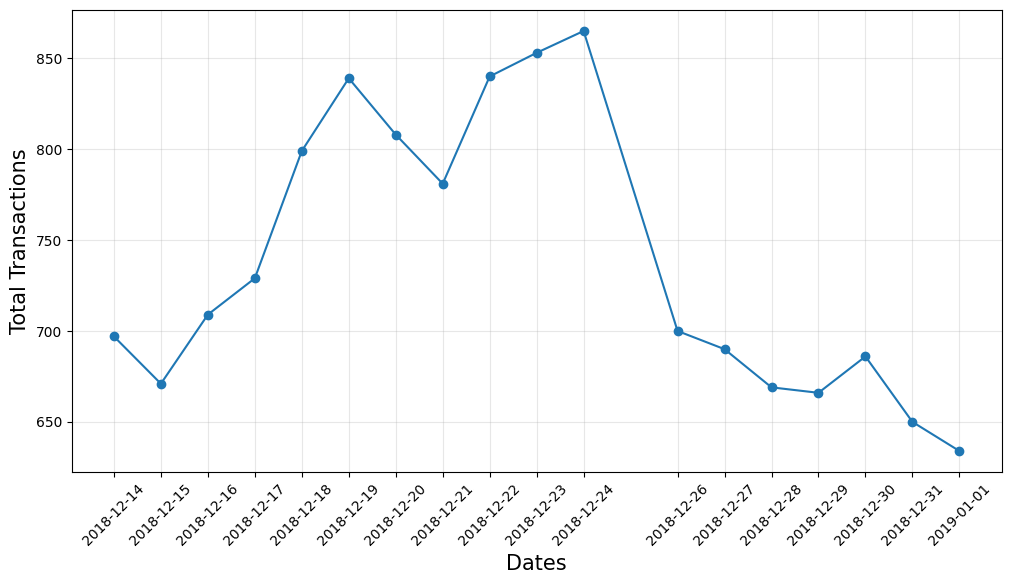

In [15]:
dec_data = safe_data[(safe_data['DATE'] >= datetime(2018,12,14)) & (safe_data['DATE'] <= datetime(2019,1,1))]

zoomin = dec_data.groupby('DATE')['TXN_ID'].count()


plt.figure(figsize= (12,6))
plt.plot(zoomin, marker= 'o');
plt.grid(True, alpha= 0.3);
plt.xticks(zoomin.index, rotation= 45 );
plt.xlabel('Dates', fontsize= 15)
plt.ylabel('Total Transactions', fontsize= 15)

## 9. Product Pack-Size Analysis

### Business Question

Which chip pack sizes are purchased most frequently?

Understanding pack-size preferences can help identify products with stronger customer demand and may provide useful information for product assortment and promotional decisions.

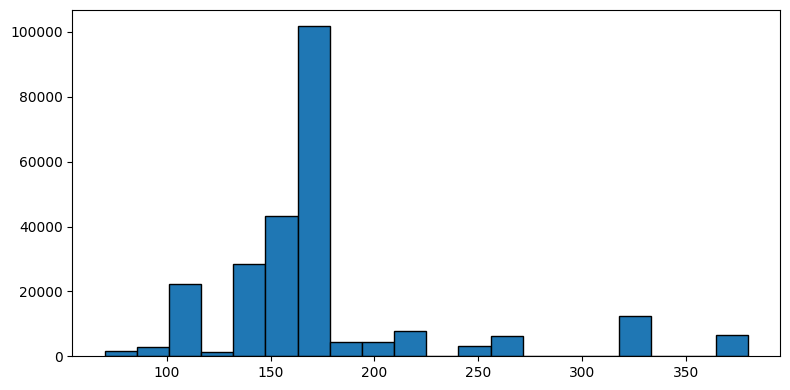

In [16]:
pkt_size = safe_data.groupby('SIZE')['TXN_ID'].count().sort_values(ascending= False)

plt.figure(figsize= (8,4));
plt.hist(safe_data['SIZE'], bins= 20, edgecolor= 'black');
plt.tight_layout()

## 10. Customer Life-Stage Analysis

### Business Question

Which customer life stages contribute most to the chip market?

I compare life stages using sales and transaction/customer counts. Looking at both measures helps distinguish between groups with a large customer presence and groups that generate higher sales.

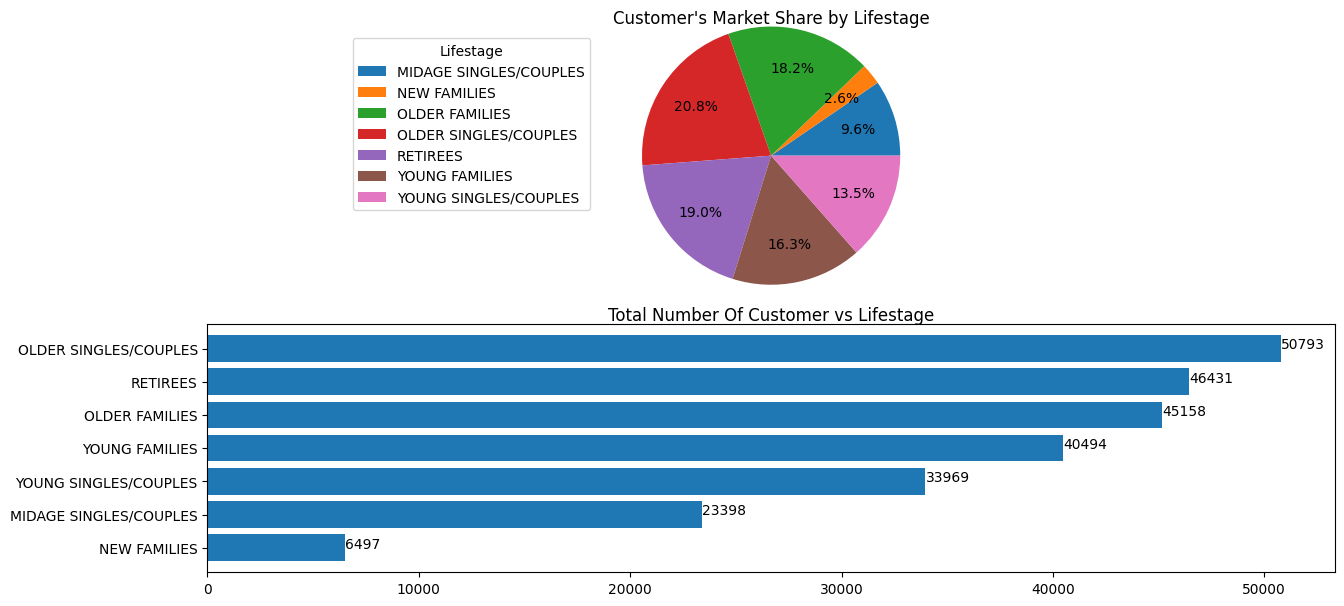

In [17]:
customer_lifestage = safe_data.groupby('LIFESTAGE')['TOT_SALES'].sum()
cust_vs_size = safe_data.groupby('LIFESTAGE')['LYLTY_CARD_NBR'].count().sort_values()

fig, ax = plt.subplots(2,1, figsize= (12,6))

fig.subplots_adjust(top=0.90, hspace=0.6)
fig.tight_layout()

ax[0].pie(customer_lifestage, autopct= '%1.1f%%', pctdistance= 0.7, radius= 1.3, center= (-1,-1));
ax[0].legend(customer_lifestage.index, title= 'Lifestage', loc= 'best', bbox_to_anchor=(-1, 0, 0.8, 1))
ax[0].set_title('Customer\'s Market Share by Lifestage');


ax[1].barh(cust_vs_size.index, cust_vs_size.values);
ax[1].set_title('Total Number Of Customer vs Lifestage', y= 0.98);

for i,v in enumerate(cust_vs_size):
    ax[1].text(v + 1, i, str(v))

## 11. Customer Segment Analysis

Customers are divided into three purchasing segments:
- Budget
- Mainstream
- Premium

### Business Question

How does purchasing behaviour differ between these three customer segments?

The analysis compares their contribution to total sales and then examines how the segments are distributed across different life stages.

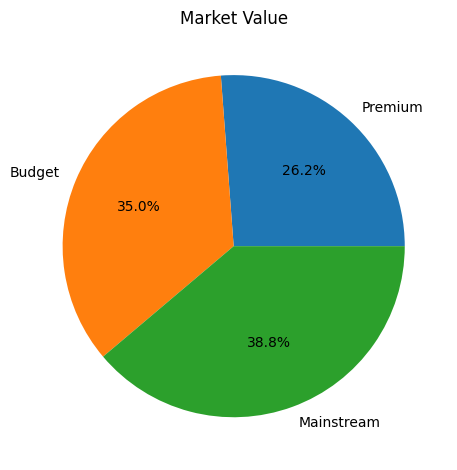

In [18]:
segment_revenu = safe_data.groupby('PREMIUM_CUSTOMER', observed= True)['TOT_SALES'].sum().sort_values()

plt.pie(segment_revenu, autopct= '%1.1f%%', labels= segment_revenu.index);
plt.title('Market Value');
plt.tight_layout();

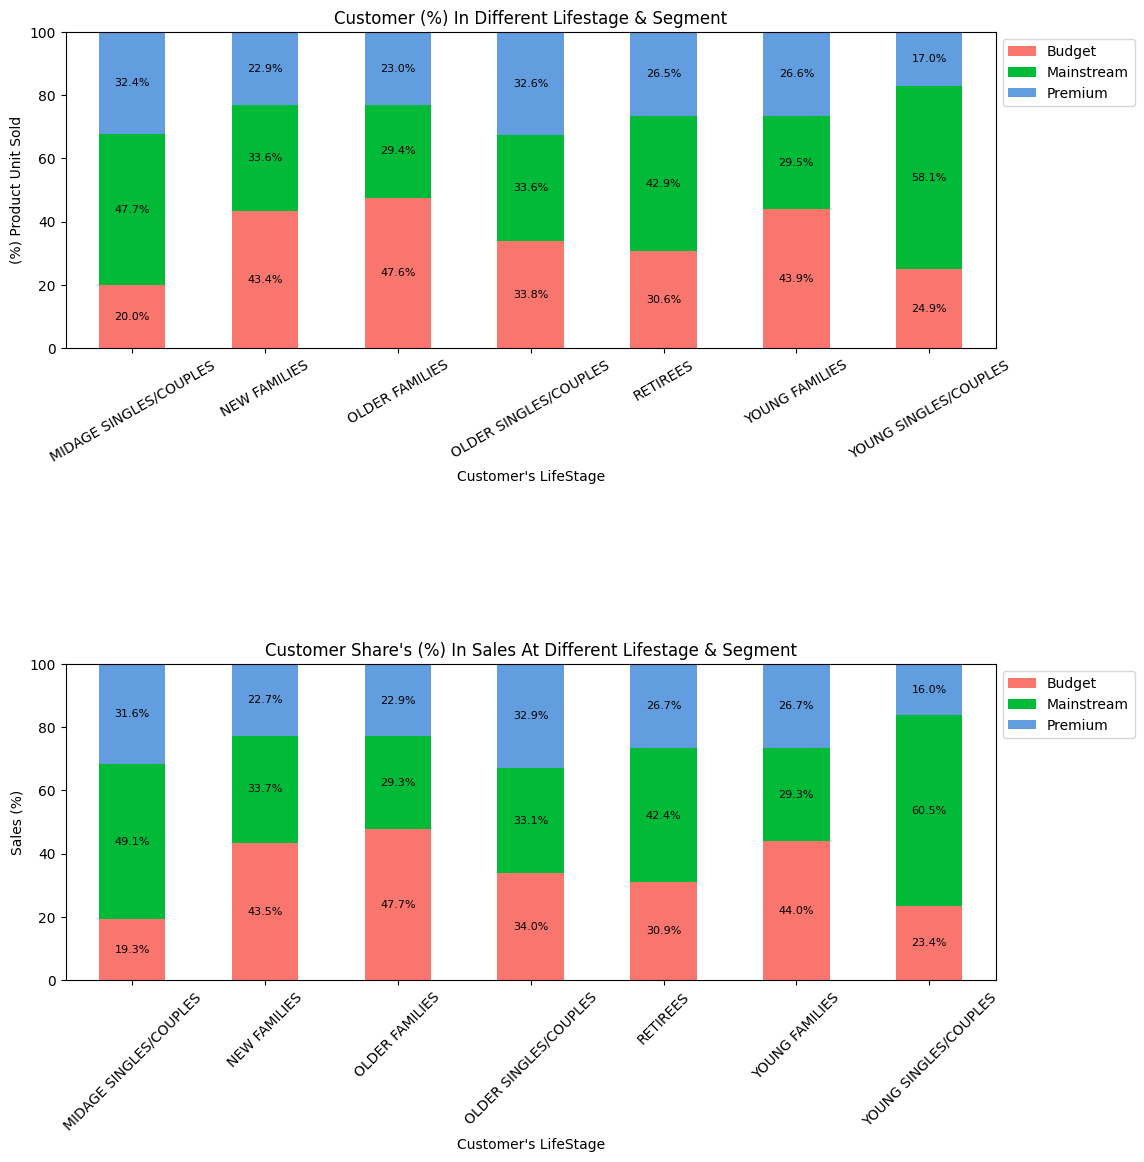

In [19]:
market_share = pd.crosstab(index= safe_data['LIFESTAGE'],
                           columns= safe_data['PREMIUM_CUSTOMER'],
                           values= safe_data['PROD_QTY'],
                           aggfunc= 'sum')

unit_sold_pct = market_share.div(market_share.sum(axis= 1), axis= 0) * 100


fig, ax = plt.subplots( 2,1 ,figsize= (12,12));
fig.subplots_adjust(top=0.90, hspace= 1);

unit_sold_pct.plot(kind= 'bar', stacked= True, ax= ax[0], color= {'Budget': '#F9766E', 'Premium': '#619DDF', 'Mainstream':'#01BA38'});
ax[0].tick_params(axis= "x", rotation=30)
ax[0].set_xlabel('Customer\'s LifeStage')
ax[0].set_ylabel('(%) Product Unit Sold')
ax[0].set_ylim(0,100)

for container in ax[0].containers:  # each stack layer
    ax[0].bar_label(container, fmt='%1.1f%%', label_type='center', fontsize=8)
ax[0].set_title('Customer (%) In Different Lifestage & Segment')
ax[0].legend(loc= 'best', bbox_to_anchor=(1, 1));


crosstab_df = pd.crosstab(index= safe_data['LIFESTAGE'],
                          columns= safe_data['PREMIUM_CUSTOMER'],
                          values= safe_data['TOT_SALES'],
                          aggfunc= 'sum')

normalized_sales = crosstab_df.div(crosstab_df.sum(axis= 1), axis= 0) * 100


normalized_sales.plot(kind= 'bar', stacked= True, ax= ax[1], color= {'Budget': '#F9766E', 'Premium': '#619DDF', 'Mainstream':'#01BA38'});
ax[1].tick_params(axis= "x", rotation=45)
ax[1].set_xlabel('Customer\'s LifeStage')
ax[1].set_ylabel('Sales (%)')
ax[1].set_ylim(0,100)
for container in ax[1].containers:  # each stack layer
    ax[1].bar_label(container, fmt='%1.1f%%', label_type='center', fontsize=8)
ax[1].set_title('Customer Share\'s (%) In Sales At Different Lifestage & Segment')
ax[1].legend(loc= 'best', bbox_to_anchor=(1, 1));

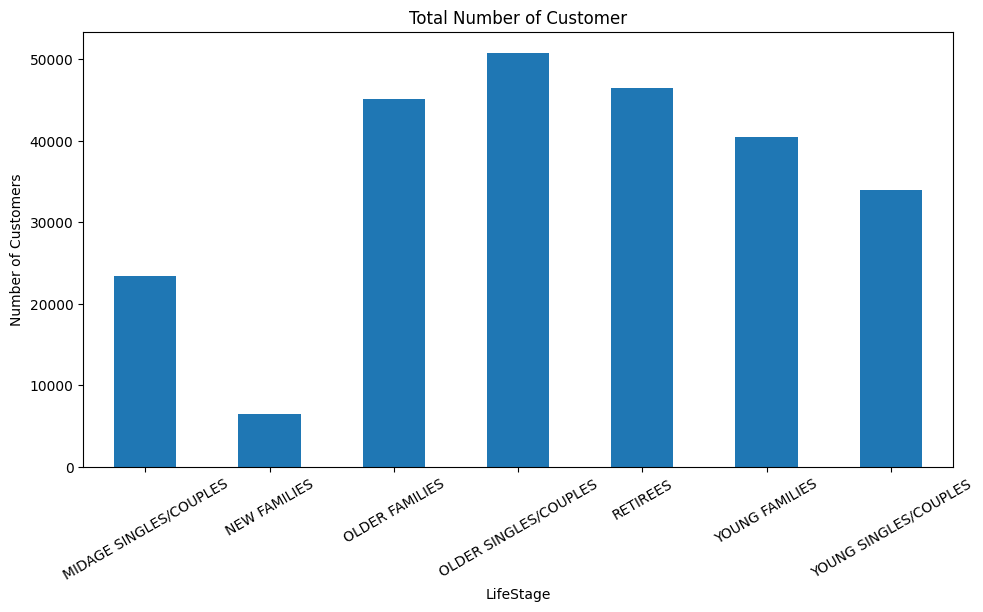

In [20]:
customer_count = safe_data.groupby('LIFESTAGE')['LYLTY_CARD_NBR'].size()

customer_count.plot(kind= 'bar', figsize= (10, 6));
plt.xticks(rotation= 30);
plt.ylabel("Number of Customers");
plt.xlabel("LifeStage");
plt.tight_layout();
plt.title("Total Number of Customer");

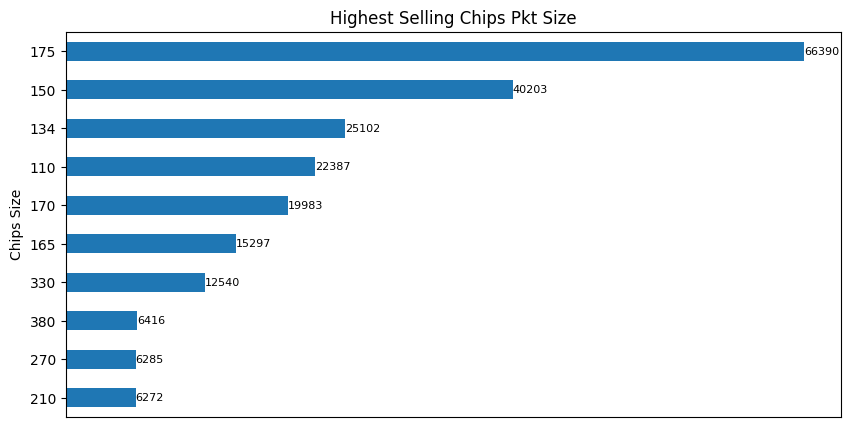

In [21]:
chip_size = safe_data.groupby('SIZE')['LYLTY_CARD_NBR'].size().sort_values()

fig, ax = plt.subplots(figsize= (10,5))
chip_size.tail(10).plot(kind= 'barh', ax= ax);
ax.xaxis.set_visible(False)
ax.set_ylabel("Chips Size");
ax.set_xlabel("Number Of Quantity Sold");
ax.set_title("Highest Selling Chips Pkt Size");
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=8)

## 12. Initial Market and Customer-Segment Findings

### Top 3 Highest-Selling Chip Pack Sizes
1. **175g**
2. **150g**
3. **134g**

The life-stage and customer-segment analysis also shows differences in purchasing contribution across Budget, Mainstream, and Premium customers.

The **Mainstream** segment is selected for deeper analysis because it represents an important share of overall sales in this dataset.

The next sections investigate which life stages are most important within the Mainstream segment and what products they prefer.

## 13. Average Unit Price Analysis

To compare purchasing behaviour across customer groups, average unit price is calculated as:

**Average Unit Price = Total Sales / Total Product Quantity**

This helps distinguish whether differences in sales are primarily associated with buying more units, paying a higher price per unit, or both.

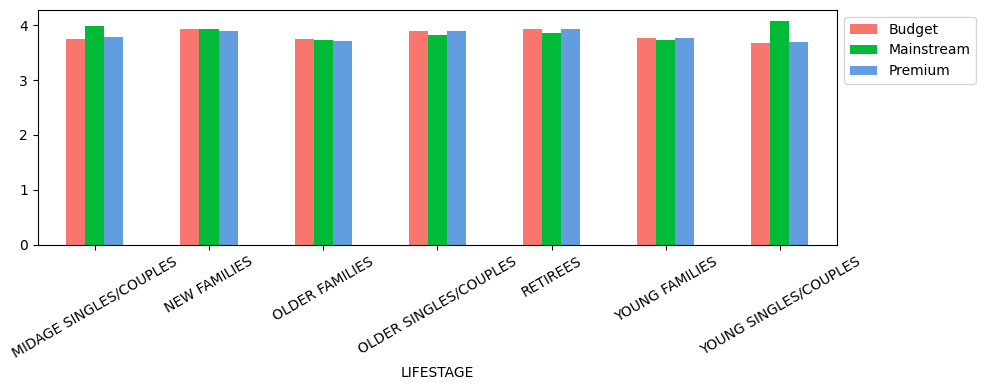

In [22]:
total_sales = pd.crosstab(index= safe_data['LIFESTAGE'],
                             columns= safe_data['PREMIUM_CUSTOMER'],
                             values= safe_data['TOT_SALES'],
                             aggfunc= 'sum',
)

total_prod_qty = pd.crosstab(index= safe_data['LIFESTAGE'],
                             columns= safe_data['PREMIUM_CUSTOMER'],
                             values= safe_data['PROD_QTY'],
                             aggfunc= 'sum',)

avg_unit_price = round((total_sales / total_prod_qty), 6)

avg_unit_price.plot(kind= 'bar', figsize= (10,4), color= {'Budget': '#F9766E', 'Premium': '#619DDF', 'Mainstream':'#01BA38'});
plt.xticks(rotation= 30);
plt.legend(bbox_to_anchor=(1, 1));
plt.tight_layout();


## 14. Mainstream Customer Opportunity

The segment and life-stage analysis identifies **Midage Singles/Couples** and **Young Singles/Couples** as important contributors within the Mainstream segment.

These groups are therefore selected for deeper analysis of:
- Average transaction value.
- Brand preference.
- Pack-size preference.
- Relative sales representation.

The objective is to move from a broad customer-segment insight toward a more actionable product-level insight.

## 15. Statistical Test: Mainstream vs Other Segments

### Business Question

Do the selected Young Singles/Couples and Midage Singles/Couples have a different average transaction sales value when purchasing Mainstream products compared with the same life-stage groups purchasing outside the Mainstream segment?

### Hypotheses

**Null Hypothesis (H0):**  
There is no difference in mean transaction sales between the two groups.

**Alternative Hypothesis (H1):**  
There is a difference in mean transaction sales between the two groups.

### Statistical Test

An independent **Welch's t-test** is used because the two groups may have unequal variances.

### Significance Level

α = 0.05


In [23]:
mainstream = safe_data[(safe_data['PREMIUM_CUSTOMER'] == 'Mainstream') & ((safe_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES') | (safe_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES'))]['TOT_SALES']

not_mainstream = safe_data[(safe_data['PREMIUM_CUSTOMER'] != 'Mainstream') & ((safe_data['LIFESTAGE'] == 'MIDAGE SINGLES/COUPLES') | (safe_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES'))]['TOT_SALES']


# print(f'Mainstream customer {mainstream}\nNot Mainstream Customer {not_mainstream}')
t_statistic, p_value = stats.ttest_ind(mainstream, not_mainstream, equal_var= False)

print(f'T-statistic: {t_statistic}\nP-value: {p_value}')

if p_value < 0.05:
    print('There is Significant Difference between both group')
else:
    print('There is NO Significat Difference between both group')

print(f'Mean of {mainstream.mean()}\n{not_mainstream.mean()}')

T-statistic: 33.06747700354075
P-value: 1.8351272129280224e-237
There is Significant Difference between both group
Mean of 7.582376956939697
6.88281774520874


### Statistical Test Result

The Welch's t-test produces:

- **t-statistic:** 33.07
- **p-value:** 1.835e-237
- **Mean transaction sales — Mainstream:** approximately $7.58
- **Mean transaction sales — Other segments:** approximately $6.88

Because the p-value is far below 0.05, the null hypothesis is rejected.

There is strong statistical evidence that the mean transaction sales differ between the two groups in this dataset.

However, statistical significance does not by itself indicate the size or business importance of the difference. The mean difference should also be considered in practical terms.

## 16. Relative Brand Sales Analysis

### Business Question

Which brands show relatively stronger sales representation among **Mainstream Young Singles/Couples**?

For each brand, I calculate a relative sales ratio:

**Target-group brand sales / comparison-group brand sales**

A higher ratio means that the brand has relatively stronger sales representation in the target group than in the selected comparison group.

> **Note:** This is a descriptive relative-sales measure, not a formal causal or predictive affinity model.

In [24]:
young_single = safe_data[(safe_data['PREMIUM_CUSTOMER'] == 'Mainstream') & (safe_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')].groupby('BRAND')['TOT_SALES'].sum()

not_young_single = safe_data[(safe_data['PREMIUM_CUSTOMER'] != 'Mainstream') & (safe_data['LIFESTAGE'] != 'YOUNG SINGLES/COUPLES')].groupby('BRAND')['TOT_SALES'].sum()

affinity = (young_single/not_young_single)

affinity.sort_values(ascending= False)

BRAND
Tyrrells      0.168684
Twisties      0.167666
Doritos       0.167507
Kettle        0.163283
Tostitos      0.162758
Pringles      0.162369
Cobs          0.159578
Infuzions     0.158596
GrnWves       0.146585
Cheezels      0.146004
Thins         0.145219
Smiths        0.121676
French        0.095080
Cheetos       0.094878
RRD           0.089861
Natural       0.087020
CCs           0.083316
Sunbites      0.069194
Woolworths    0.067990
Burger        0.061521
Name: TOT_SALES, dtype: float32

## 17. Relative Pack-Size Sales Analysis

The same relative-sales approach is applied to pack size.

The objective is to identify which pack sizes have relatively stronger sales representation among Mainstream Young Singles/Couples compared with the selected comparison group.

In [25]:
young_single_size = safe_data[(safe_data['PREMIUM_CUSTOMER'] == 'Mainstream') & (safe_data['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES')].groupby('SIZE')['TOT_SALES'].sum()

not_young_single_size = safe_data[(safe_data['PREMIUM_CUSTOMER'] != 'Mainstream') & (safe_data['LIFESTAGE'] != 'YOUNG SINGLES/COUPLES')].groupby('SIZE')['TOT_SALES'].sum()


affinity_size = (young_single_size/not_young_single_size)

affinity_size.sort_values(ascending= False)

SIZE
270    0.174512
380    0.172192
330    0.165252
110    0.163101
134    0.162369
210    0.160848
135    0.156984
250    0.153392
170    0.146351
150    0.142149
175    0.138542
165    0.130839
190    0.090856
180    0.079853
160    0.072027
125    0.069206
90     0.069194
200    0.066763
70     0.066425
220    0.061521
Name: TOT_SALES, dtype: float32

### Pack-Size Finding

The **270g** pack size has the highest relative sales ratio among the analyzed pack sizes, followed by 380g and 330g.

This makes 270g a candidate for further product-level investigation within the target customer group.

## 18. Product-Level Investigation

The 270g pack size has the highest relative sales ratio in the target-group pack-size analysis.

I therefore inspect the brands and individual products within the 270g category to identify the products contributing to this preference.

In [26]:
top_seller = safe_data[safe_data['SIZE'] == 270][['BRAND','PROD_NAME','SIZE']]

top_seller.drop_duplicates()

,BRAND,PROD_NAME,SIZE
12,Twisties,Twisties Cheese 270g,270
42,Twisties,Twisties Chicken270g,270


### Product-Level Finding

The 270g category contains:
- **Twisties Cheese 270g**
- **Twisties Chicken270g**

These products are candidates for further investigation when considering purchasing behaviour within the target customer group.

# 19. Final Business Insights

## Key Findings

### 1. Transaction Behaviour
Transaction activity varies over time, with specific periods suitable for closer investigation.

### 2. Pack-Size Preference
**175g, 150g, and 134g** are the three highest-selling pack sizes identified in the cleaned transaction data.

### 3. Customer Life Stage
Purchasing behaviour differs across customer life stages, with different groups contributing differently to market sales.

### 4. Customer Segmentation
The **Mainstream** segment is an important contributor to overall sales and was selected for deeper analysis.

### 5. Target Customer Groups
**Young Singles/Couples** and **Midage Singles/Couples** were selected for deeper investigation within the Mainstream segment.

### 6. Statistical Evidence
The Welch's t-test indicates a statistically significant difference in average transaction sales between the selected Mainstream group and the comparison group.

### 7. Product Preference
The **270g** pack size has the highest relative sales ratio in the target-group pack-size analysis. The 270g category contains Twisties Cheese 270g and Twisties Chicken270g.

## Business Takeaway

The workflow moves from:

**Raw Transactions → Data Cleaning → Customer Segmentation → Sales Analysis → Statistical Testing → Product Preference → Business Recommendation**

This demonstrates how transaction-level data can be transformed into customer and product insights that can support further business investigation.